In [1]:
# ================================================================
# REGIME-AWARE MULTIFACTOR PORTFOLIO
# PART 1: DATA COLLECTION & PREPARATION
# ================================================================

!pip -q install yfinance

import numpy as np
import pandas as pd
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")

print("=" * 75)
print("REGIME-AWARE MULTIFACTOR PORTFOLIO")
print("PART 1: DATA COLLECTION & PREPARATION")
print("=" * 75)


# ---------------------------------------------------------------
# 1. STOCK UNIVERSE
# ---------------------------------------------------------------

stocks = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "SBIN.NS",
    "ITC.NS",
    "SUNPHARMA.NS",
    "MARUTI.NS",
    "NTPC.NS",
    "ADANIENT.NS",
    "LT.NS"
]

benchmark = "^NSEI"

print("\nSelected stocks:")
print(stocks)

print("\nBenchmark:")
print("NIFTY 50")


# ---------------------------------------------------------------
# 2. DOWNLOAD STOCK DATA
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("DOWNLOADING STOCK PRICE DATA")
print("=" * 75)

data = yf.download(
    stocks,
    start="2015-01-01",
    end="2026-08-20",
    auto_adjust=True,
    progress=False
)

# Extract closing prices
prices = data["Close"]

# Remove stocks with excessive missing observations
prices = prices.dropna(axis=1, thresh=int(len(prices) * 0.90))

# Forward fill small gaps
prices = prices.ffill()

print("Price observations :", len(prices))
print("Assets              :", len(prices.columns))
print("Start               :", prices.index.min())
print("End                 :", prices.index.max())


# ---------------------------------------------------------------
# 3. DOWNLOAD NIFTY 50
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("DOWNLOADING NIFTY 50")
print("=" * 75)

nifty = yf.download(
    benchmark,
    start="2015-01-01",
    end="2026-08-20",
    auto_adjust=True,
    progress=False
)["Close"]

# Convert to Series if necessary
if isinstance(nifty, pd.DataFrame):
    nifty = nifty.iloc[:, 0]

nifty = nifty.ffill()

print("NIFTY observations :", len(nifty))
print("Start              :", nifty.index.min())
print("End                :", nifty.index.max())


# ---------------------------------------------------------------
# 4. CALCULATE DAILY RETURNS
# ---------------------------------------------------------------

stock_returns = prices.pct_change()

nifty_returns = nifty.pct_change()

# Remove first NaN
stock_returns = stock_returns.dropna()
nifty_returns = nifty_returns.dropna()

print("\n" + "=" * 75)
print("RETURN DATA")
print("=" * 75)

print("Stock return observations :", len(stock_returns))
print("NIFTY return observations :", len(nifty_returns))


# ---------------------------------------------------------------
# 5. ALIGN STOCKS AND BENCHMARK
# ---------------------------------------------------------------

common_dates = stock_returns.index.intersection(
    nifty_returns.index
)

stock_returns = stock_returns.loc[common_dates]
nifty_returns = nifty_returns.loc[common_dates]

prices = prices.loc[common_dates]
nifty = nifty.loc[common_dates]

print("\nCommon observations :", len(common_dates))


# ---------------------------------------------------------------
# 6. BASIC DATA QUALITY CHECK
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("DATA QUALITY CHECK")
print("=" * 75)

missing = prices.isna().sum()

print("\nMissing observations:")
print(missing)

print("\nFinal stock universe:")
print(list(prices.columns))


# ---------------------------------------------------------------
# 7. MARKET VARIABLES FOR HMM
# ---------------------------------------------------------------

# Rolling market volatility
nifty_volatility = nifty_returns.rolling(21).std() * np.sqrt(252)

# Rolling market return
nifty_21d_return = nifty.pct_change(21)

# Remove initial missing observations
market_features = pd.DataFrame({
    "NIFTY_Return": nifty_returns,
    "NIFTY_21D_Return": nifty_21d_return,
    "NIFTY_Volatility": nifty_volatility
}).dropna()


# ---------------------------------------------------------------
# 8. SUMMARY STATISTICS
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("MARKET SUMMARY")
print("=" * 75)

annual_return = nifty_returns.mean() * 252
annual_volatility = nifty_returns.std() * np.sqrt(252)

print(f"NIFTY Annualized Return     : {annual_return:.2%}")
print(f"NIFTY Annualized Volatility : {annual_volatility:.2%}")


# ---------------------------------------------------------------
# 9. SAVE DATA
# ---------------------------------------------------------------

prices.to_csv("regime_multifactor_prices.csv")
stock_returns.to_csv("regime_multifactor_returns.csv")
market_features.to_csv("nifty_market_features.csv")

print("\n" + "=" * 75)
print("FILES SAVED")
print("=" * 75)

print("regime_multifactor_prices.csv")
print("regime_multifactor_returns.csv")
print("nifty_market_features.csv")

print("\nPART 1 COMPLETED")
print("=" * 75)

REGIME-AWARE MULTIFACTOR PORTFOLIO
PART 1: DATA COLLECTION & PREPARATION

Selected stocks:
['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'SBIN.NS', 'ITC.NS', 'SUNPHARMA.NS', 'MARUTI.NS', 'NTPC.NS', 'ADANIENT.NS', 'LT.NS']

Benchmark:
NIFTY 50

DOWNLOADING STOCK PRICE DATA
Price observations : 2875
Assets              : 12
Start               : 2015-01-01 00:00:00
End                 : 2026-08-19 00:00:00

DOWNLOADING NIFTY 50
NIFTY observations : 2863
Start              : 2015-01-02 00:00:00
End                : 2026-08-19 00:00:00

RETURN DATA
Stock return observations : 2874
NIFTY return observations : 2862

Common observations : 2862

DATA QUALITY CHECK

Missing observations:
Ticker
ADANIENT.NS     0
HDFCBANK.NS     0
ICICIBANK.NS    0
INFY.NS         0
ITC.NS          0
LT.NS           0
MARUTI.NS       0
NTPC.NS         0
RELIANCE.NS     0
SBIN.NS         0
SUNPHARMA.NS    0
TCS.NS          0
dtype: int64

Final stock universe:
['ADANIENT.NS', 'HDFCBANK.NS', 

In [2]:
# ================================================================
# REGIME-AWARE MULTIFACTOR PORTFOLIO
# PART 2: MULTIFACTOR CONSTRUCTION + Z-SCORES
# ================================================================

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

print("=" * 75)
print("REGIME-AWARE MULTIFACTOR PORTFOLIO")
print("PART 2: MULTIFACTOR CONSTRUCTION + Z-SCORES")
print("=" * 75)


# ---------------------------------------------------------------
# 1. LOAD DATA FROM PART 1
# ---------------------------------------------------------------

prices = pd.read_csv(
    "regime_multifactor_prices.csv",
    index_col=0,
    parse_dates=True
)

returns = pd.read_csv(
    "regime_multifactor_returns.csv",
    index_col=0,
    parse_dates=True
)

prices = prices.sort_index()
returns = returns.sort_index()

print("\nPrice observations :", len(prices))
print("Assets              :", len(prices.columns))


# ---------------------------------------------------------------
# 2. FACTOR PARAMETERS
# ---------------------------------------------------------------

# Momentum:
# 12-month return excluding the most recent month

MOMENTUM_LOOKBACK = 252
MOMENTUM_SKIP = 21

# Low volatility:
# 3-month realized volatility

VOL_LOOKBACK = 63

# Quality:
# Return on equity proxy using price-based profitability
# We use 12-month return as a simple market-based quality proxy
QUALITY_LOOKBACK = 252

# Value:
# Price-to-book requires fundamental data and can create
# survivorship/data-availability issues.
#
# Therefore, for this project we use a valuation proxy:
# earnings-yield-style inverse of trailing price momentum.
#
# A cleaner fundamental Value factor can be substituted later.


# ---------------------------------------------------------------
# 3. MOMENTUM FACTOR
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("CALCULATING MOMENTUM FACTOR")
print("=" * 75)

momentum = (
    prices.shift(MOMENTUM_SKIP)
    / prices.shift(MOMENTUM_LOOKBACK)
    - 1
)

print("Momentum lookback :", MOMENTUM_LOOKBACK, "days")
print("Recent period excluded :", MOMENTUM_SKIP, "days")


# ---------------------------------------------------------------
# 4. LOW-VOLATILITY FACTOR
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("CALCULATING LOW-VOLATILITY FACTOR")
print("=" * 75)

realized_volatility = (
    returns.rolling(VOL_LOOKBACK).std()
    * np.sqrt(252)
)

# Lower volatility = higher factor score
low_volatility = -realized_volatility

print("Volatility window :", VOL_LOOKBACK, "days")


# ---------------------------------------------------------------
# 5. QUALITY FACTOR
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("CALCULATING QUALITY FACTOR")
print("=" * 75)

# Stable long-term return proxy
quality = returns.rolling(
    QUALITY_LOOKBACK
).mean() / returns.rolling(
    QUALITY_LOOKBACK
).std()

print("Quality window :", QUALITY_LOOKBACK, "days")


# ---------------------------------------------------------------
# 6. VALUE FACTOR
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("CALCULATING VALUE FACTOR")
print("=" * 75)

# Long-term price-to-return proxy.
# Stocks with lower long-term valuation-adjusted price growth
# receive relatively higher value scores.

long_term_return = (
    prices / prices.shift(QUALITY_LOOKBACK) - 1
)

value = -long_term_return

print("Value proxy calculated.")


# ---------------------------------------------------------------
# 7. CROSS-SECTIONAL Z-SCORE FUNCTION
# ---------------------------------------------------------------

def cross_sectional_zscore(df):

    mean = df.mean(axis=1)

    std = df.std(axis=1)

    z = df.sub(mean, axis=0).div(
        std.replace(0, np.nan),
        axis=0
    )

    return z


# ---------------------------------------------------------------
# 8. CALCULATE FACTOR Z-SCORES
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("CALCULATING FACTOR Z-SCORES")
print("=" * 75)

momentum_z = cross_sectional_zscore(momentum)

low_vol_z = cross_sectional_zscore(low_volatility)

quality_z = cross_sectional_zscore(quality)

value_z = cross_sectional_zscore(value)


# ---------------------------------------------------------------
# 9. COMPOSITE MULTIFACTOR SCORE
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("CREATING COMPOSITE MULTIFACTOR SCORE")
print("=" * 75)

# Equal-weighted factor model

composite_score = (
    0.25 * momentum_z +
    0.25 * value_z +
    0.25 * quality_z +
    0.25 * low_vol_z
)

print("\nFactor weights:")
print("Momentum       : 25%")
print("Value          : 25%")
print("Quality        : 25%")
print("Low Volatility : 25%")


# ---------------------------------------------------------------
# 10. CLEAN EXTREME / INVALID VALUES
# ---------------------------------------------------------------

composite_score = composite_score.replace(
    [np.inf, -np.inf],
    np.nan
)


# ---------------------------------------------------------------
# 11. DISPLAY LATEST FACTOR SCORES
# ---------------------------------------------------------------

latest_date = composite_score.dropna(
    how="all"
).index[-1]

latest_scores = pd.DataFrame({
    "Momentum_Z": momentum_z.loc[latest_date],
    "Value_Z": value_z.loc[latest_date],
    "Quality_Z": quality_z.loc[latest_date],
    "LowVol_Z": low_vol_z.loc[latest_date],
    "Composite_Z": composite_score.loc[latest_date]
}).dropna()

latest_scores = latest_scores.sort_values(
    "Composite_Z",
    ascending=False
)

print("\n" + "=" * 75)
print("LATEST MULTIFACTOR SCORES")
print("=" * 75)

print(latest_scores.round(3))


# ---------------------------------------------------------------
# 12. CREATE TOP-RANKED STOCK LIST
# ---------------------------------------------------------------

TOP_N = 8

selected_assets = latest_scores.head(
    TOP_N
).index.tolist()

print("\n" + "=" * 75)
print("TOP MULTIFACTOR STOCKS")
print("=" * 75)

for i, ticker in enumerate(selected_assets, 1):
    print(
        f"{i:2d}. {ticker:<18} "
        f"Score: {latest_scores.loc[ticker, 'Composite_Z']:.3f}"
    )


# ---------------------------------------------------------------
# 13. SAVE FACTOR DATA
# ---------------------------------------------------------------

momentum_z.to_csv(
    "momentum_zscores.csv"
)

value_z.to_csv(
    "value_zscores.csv"
)

quality_z.to_csv(
    "quality_zscores.csv"
)

low_vol_z.to_csv(
    "low_volatility_zscores.csv"
)

composite_score.to_csv(
    "multifactor_composite_scores.csv"
)

latest_scores.to_csv(
    "latest_multifactor_scores.csv"
)

print("\n" + "=" * 75)
print("FILES SAVED")
print("=" * 75)

print("momentum_zscores.csv")
print("value_zscores.csv")
print("quality_zscores.csv")
print("low_volatility_zscores.csv")
print("multifactor_composite_scores.csv")
print("latest_multifactor_scores.csv")

print("\nPART 2 COMPLETED")
print("=" * 75)

REGIME-AWARE MULTIFACTOR PORTFOLIO
PART 2: MULTIFACTOR CONSTRUCTION + Z-SCORES

Price observations : 2862
Assets              : 12

CALCULATING MOMENTUM FACTOR
Momentum lookback : 252 days
Recent period excluded : 21 days

CALCULATING LOW-VOLATILITY FACTOR
Volatility window : 63 days

CALCULATING QUALITY FACTOR
Quality window : 252 days

CALCULATING VALUE FACTOR
Value proxy calculated.

CALCULATING FACTOR Z-SCORES

CREATING COMPOSITE MULTIFACTOR SCORE

Factor weights:
Momentum       : 25%
Value          : 25%
Quality        : 25%
Low Volatility : 25%

LATEST MULTIFACTOR SCORES
              Momentum_Z  Value_Z  Quality_Z  LowVol_Z  Composite_Z
SUNPHARMA.NS       0.939   -0.861      1.046     1.051        0.544
SBIN.NS            1.251   -1.385      1.304     0.569        0.435
NTPC.NS            0.189   -0.086      0.225     0.489        0.204
ICICIBANK.NS       0.013    0.088      0.020     0.607        0.182
ADANIENT.NS        1.838   -1.588      1.057    -0.652        0.164
LT.NS   

In [3]:
# ================================================================
# REGIME-AWARE MULTIFACTOR PORTFOLIO
# PART 3: HMM MARKET REGIME DETECTION
# ================================================================

!pip -q install hmmlearn

import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
import warnings

warnings.filterwarnings("ignore")

print("=" * 75)
print("REGIME-AWARE MULTIFACTOR PORTFOLIO")
print("PART 3: HMM MARKET REGIME DETECTION")
print("=" * 75)


# ---------------------------------------------------------------
# 1. LOAD MARKET DATA
# ---------------------------------------------------------------

market = pd.read_csv(
    "nifty_market_features.csv",
    index_col=0,
    parse_dates=True
)

market = market.sort_index()

print("\nMarket observations :", len(market))
print("Start               :", market.index.min())
print("End                 :", market.index.max())


# ---------------------------------------------------------------
# 2. SELECT HMM FEATURES
# ---------------------------------------------------------------

features = [
    "NIFTY_Return",
    "NIFTY_21D_Return",
    "NIFTY_Volatility"
]

X = market[features].copy()

X = X.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

print("\nHMM features:")
print(features)


# ---------------------------------------------------------------
# 3. STANDARDIZE FEATURES
# ---------------------------------------------------------------

X_mean = X.mean()
X_std = X.std()

X_scaled = (X - X_mean) / X_std


# ---------------------------------------------------------------
# 4. TRAIN HMM
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("FITTING HIDDEN MARKOV MODEL")
print("=" * 75)

N_REGIMES = 3

hmm_model = GaussianHMM(
    n_components=N_REGIMES,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

hmm_model.fit(X_scaled.values)


# ---------------------------------------------------------------
# 5. PREDICT MARKET REGIMES
# ---------------------------------------------------------------

regimes = hmm_model.predict(
    X_scaled.values
)

market["Regime"] = regimes

print("\nHMM regimes detected :", N_REGIMES)


# ---------------------------------------------------------------
# 6. ANALYZE EACH REGIME
# ---------------------------------------------------------------

regime_statistics = (
    market
    .groupby("Regime")
    .agg(
        Mean_Return=("NIFTY_Return", "mean"),
        Volatility=("NIFTY_Return", "std"),
        Mean_21D_Return=("NIFTY_21D_Return", "mean"),
        Mean_Market_Volatility=("NIFTY_Volatility", "mean"),
        Observations=("NIFTY_Return", "count")
    )
)

regime_statistics["Annualized_Return"] = (
    regime_statistics["Mean_Return"] * 252
)

regime_statistics["Annualized_Volatility"] = (
    regime_statistics["Volatility"] * np.sqrt(252)
)

print("\n" + "=" * 75)
print("RAW HMM REGIME STATISTICS")
print("=" * 75)

print(
    regime_statistics.round(4)
)


# ---------------------------------------------------------------
# 7. LABEL THE REGIMES
# ---------------------------------------------------------------

# We identify:
# Highest return regime -> Bull
# Lowest return regime  -> Bear
# Remaining regime      -> High/Low Volatility depending on vol

return_ranking = (
    regime_statistics["Mean_Return"]
    .sort_values()
)

bear_regime = return_ranking.index[0]
bull_regime = return_ranking.index[-1]

remaining = [
    r for r in range(N_REGIMES)
    if r not in [bear_regime, bull_regime]
]

if remaining:

    middle_regime = remaining[0]

    # Determine whether middle regime is relatively volatile
    vol_values = regime_statistics["Volatility"]

    if vol_values[middle_regime] >= vol_values.median():
        middle_label = "High Volatility"
    else:
        middle_label = "Low Volatility"

else:
    middle_regime = None
    middle_label = "Other"


regime_labels = {
    bear_regime: "Bear",
    bull_regime: "Bull"
}

if middle_regime is not None:
    regime_labels[middle_regime] = middle_label


market["Regime_Label"] = market["Regime"].map(
    regime_labels
)


# ---------------------------------------------------------------
# 8. DISPLAY FINAL REGIME CLASSIFICATION
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("REGIME CLASSIFICATION")
print("=" * 75)

for regime in sorted(regime_labels):

    row = regime_statistics.loc[regime]

    print(
        f"\nRegime {regime} → {regime_labels[regime]}"
    )

    print(
        f"Average Return       : "
        f"{row['Mean_Return']:.4%}"
    )

    print(
        f"Annualized Volatility : "
        f"{row['Annualized_Volatility']:.2%}"
    )

    print(
        f"Observations          : "
        f"{int(row['Observations'])}"
    )


# ---------------------------------------------------------------
# 9. REGIME FREQUENCY
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("REGIME FREQUENCY")
print("=" * 75)

regime_frequency = (
    market["Regime_Label"]
    .value_counts()
)

regime_percentage = (
    market["Regime_Label"]
    .value_counts(normalize=True) * 100
)

regime_frequency_table = pd.DataFrame({
    "Observations": regime_frequency,
    "Percentage": regime_percentage
})

print(
    regime_frequency_table.round(2)
)


# ---------------------------------------------------------------
# 10. CURRENT MARKET REGIME
# ---------------------------------------------------------------

latest_date = market.index[-1]

current_regime = market.loc[
    latest_date,
    "Regime_Label"
]

print("\n" + "=" * 75)
print("CURRENT MARKET REGIME")
print("=" * 75)

print("Date   :", latest_date.date())
print("Regime :", current_regime)


# ---------------------------------------------------------------
# 11. SAVE RESULTS
# ---------------------------------------------------------------

market.to_csv(
    "nifty_hmm_regimes.csv"
)

regime_statistics.to_csv(
    "hmm_regime_statistics.csv"
)

regime_frequency_table.to_csv(
    "hmm_regime_frequency.csv"
)

print("\n" + "=" * 75)
print("FILES SAVED")
print("=" * 75)

print("nifty_hmm_regimes.csv")
print("hmm_regime_statistics.csv")
print("hmm_regime_frequency.csv")

print("\nPART 3 COMPLETED")
print("=" * 75)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 2.6 MB/s eta 0:00:00
REGIME-AWARE MULTIFACTOR PORTFOLIO
PART 3: HMM MARKET REGIME DETECTION

Market observations : 2841
Start               : 2015-02-04 00:00:00
End                 : 2026-08-19 00:00:00

HMM features:
['NIFTY_Return', 'NIFTY_21D_Return', 'NIFTY_Volatility']

FITTING HIDDEN MARKOV MODEL

HMM regimes detected : 3

RAW HMM REGIME STATISTICS
        Mean_Return  Volatility  Mean_21D_Return  Mean_Market_Volatility  \
Regime                                                                     
0            0.0013      0.0233          -0.0086                  0.3305   
1            0.0003      0.0103           0.0112                  0.1621   
2            0.0003      0.0065           0.0098                  0.1007   

        Observations  Annualized_Return  Annualized_Volatility  
Regime                                                          
0                218             0.3387                 0.3692  
1      

In [4]:
# ================================================================
# REGIME-AWARE MULTIFACTOR PORTFOLIO
# PART 4: DYNAMIC FACTOR ALLOCATION
# ================================================================

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

print("=" * 75)
print("REGIME-AWARE MULTIFACTOR PORTFOLIO")
print("PART 4: DYNAMIC FACTOR ALLOCATION")
print("=" * 75)


# ---------------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------------

momentum_z = pd.read_csv(
    "momentum_zscores.csv",
    index_col=0,
    parse_dates=True
)

value_z = pd.read_csv(
    "value_zscores.csv",
    index_col=0,
    parse_dates=True
)

quality_z = pd.read_csv(
    "quality_zscores.csv",
    index_col=0,
    parse_dates=True
)

low_vol_z = pd.read_csv(
    "low_volatility_zscores.csv",
    index_col=0,
    parse_dates=True
)

market = pd.read_csv(
    "nifty_hmm_regimes.csv",
    index_col=0,
    parse_dates=True
)

# Make sure everything is sorted
momentum_z = momentum_z.sort_index()
value_z = value_z.sort_index()
quality_z = quality_z.sort_index()
low_vol_z = low_vol_z.sort_index()
market = market.sort_index()


# ---------------------------------------------------------------
# 2. ALIGN DATA
# ---------------------------------------------------------------

common_dates = (
    momentum_z.index
    .intersection(value_z.index)
    .intersection(quality_z.index)
    .intersection(low_vol_z.index)
    .intersection(market.index)
)

momentum_z = momentum_z.loc[common_dates]
value_z = value_z.loc[common_dates]
quality_z = quality_z.loc[common_dates]
low_vol_z = low_vol_z.loc[common_dates]
market = market.loc[common_dates]


# ---------------------------------------------------------------
# 3. DEFINE REGIME-SPECIFIC FACTOR WEIGHTS
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("REGIME-SPECIFIC FACTOR WEIGHTS")
print("=" * 75)

# These are the strategic factor tilts.
#
# Bull:
# Momentum receives the highest weight.
#
# Bear:
# Quality and Low Volatility receive greater weight.
#
# High Volatility:
# Low Volatility and Quality receive greater weight.

factor_weights = {

    "Bull": {
        "Momentum": 0.40,
        "Value": 0.20,
        "Quality": 0.20,
        "LowVol": 0.20
    },

    "Bear": {
        "Momentum": 0.15,
        "Value": 0.25,
        "Quality": 0.35,
        "LowVol": 0.25
    },

    "High Volatility": {
        "Momentum": 0.15,
        "Value": 0.20,
        "Quality": 0.30,
        "LowVol": 0.35
    },

    "Low Volatility": {
        "Momentum": 0.30,
        "Value": 0.25,
        "Quality": 0.25,
        "LowVol": 0.20
    }
}


for regime, weights in factor_weights.items():

    print(f"\n{regime}")

    for factor, weight in weights.items():
        print(
            f"{factor:<15}: {weight:.0%}"
        )


# ---------------------------------------------------------------
# 4. CREATE DYNAMIC COMPOSITE SCORE
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("CREATING DYNAMIC MULTIFACTOR SCORES")
print("=" * 75)

dynamic_scores = pd.DataFrame(
    index=common_dates,
    columns=momentum_z.columns,
    dtype=float
)

dynamic_weights = []


for date in common_dates:

    regime = market.loc[
        date,
        "Regime_Label"
    ]

    # Fallback in case an unexpected label appears
    if regime not in factor_weights:
        regime = "Low Volatility"

    weights = factor_weights[regime]

    score = (
        weights["Momentum"] *
        momentum_z.loc[date]
        +
        weights["Value"] *
        value_z.loc[date]
        +
        weights["Quality"] *
        quality_z.loc[date]
        +
        weights["LowVol"] *
        low_vol_z.loc[date]
    )

    dynamic_scores.loc[date] = score

    dynamic_weights.append({
        "Date": date,
        "Regime": regime,
        "Momentum": weights["Momentum"],
        "Value": weights["Value"],
        "Quality": weights["Quality"],
        "LowVol": weights["LowVol"]
    })


dynamic_weights = pd.DataFrame(
    dynamic_weights
).set_index("Date")


# ---------------------------------------------------------------
# 5. LATEST REGIME AND SCORES
# ---------------------------------------------------------------

latest_date = dynamic_scores.dropna(
    how="all"
).index[-1]

latest_regime = market.loc[
    latest_date,
    "Regime_Label"
]

latest_scores = dynamic_scores.loc[
    latest_date
].dropna().sort_values(
    ascending=False
)


print("\n" + "=" * 75)
print("CURRENT MARKET REGIME")
print("=" * 75)

print("Date   :", latest_date.date())
print("Regime :", latest_regime)


print("\n" + "=" * 75)
print("LATEST DYNAMIC MULTIFACTOR RANKING")
print("=" * 75)

for rank, (ticker, score) in enumerate(
    latest_scores.items(),
    1
):

    print(
        f"{rank:2d}. "
        f"{ticker:<18} "
        f"Score: {score:.4f}"
    )


# ---------------------------------------------------------------
# 6. SELECT TOP STOCKS
# ---------------------------------------------------------------

TOP_N = 8

selected_assets = latest_scores.head(
    TOP_N
).index.tolist()

print("\n" + "=" * 75)
print("SELECTED ASSETS")
print("=" * 75)

print(selected_assets)


# ---------------------------------------------------------------
# 7. REGIME WEIGHT HISTORY
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("REGIME FACTOR WEIGHT HISTORY")
print("=" * 75)

print(
    dynamic_weights.tail(10).round(3)
)


# ---------------------------------------------------------------
# 8. REGIME DISTRIBUTION
# ---------------------------------------------------------------

regime_distribution = (
    dynamic_weights["Regime"]
    .value_counts()
)

print("\n" + "=" * 75)
print("REGIME DISTRIBUTION")
print("=" * 75)

print(regime_distribution)


# ---------------------------------------------------------------
# 9. SAVE RESULTS
# ---------------------------------------------------------------

dynamic_scores.to_csv(
    "dynamic_multifactor_scores.csv"
)

dynamic_weights.to_csv(
    "dynamic_factor_weights.csv"
)

pd.DataFrame({
    "Ticker": selected_assets,
    "Dynamic_Score": [
        latest_scores[t]
        for t in selected_assets
    ]
}).to_csv(
    "current_dynamic_stock_selection.csv",
    index=False
)


print("\n" + "=" * 75)
print("FILES SAVED")
print("=" * 75)

print("dynamic_multifactor_scores.csv")
print("dynamic_factor_weights.csv")
print("current_dynamic_stock_selection.csv")

print("\nPART 4 COMPLETED")
print("=" * 75)

REGIME-AWARE MULTIFACTOR PORTFOLIO
PART 4: DYNAMIC FACTOR ALLOCATION

REGIME-SPECIFIC FACTOR WEIGHTS

Bull
Momentum       : 40%
Value          : 20%
Quality        : 20%
LowVol         : 20%

Bear
Momentum       : 15%
Value          : 25%
Quality        : 35%
LowVol         : 25%

High Volatility
Momentum       : 15%
Value          : 20%
Quality        : 30%
LowVol         : 35%

Low Volatility
Momentum       : 30%
Value          : 25%
Quality        : 25%
LowVol         : 20%

CREATING DYNAMIC MULTIFACTOR SCORES

CURRENT MARKET REGIME
Date   : 2026-08-19
Regime : Low Volatility

LATEST DYNAMIC MULTIFACTOR RANKING
 1. SUNPHARMA.NS       Score: 0.5383
 2. SBIN.NS            Score: 0.4690
 3. ADANIENT.NS        Score: 0.2885
 4. NTPC.NS            Score: 0.1892
 5. ICICIBANK.NS       Score: 0.1525
 6. LT.NS              Score: 0.1507
 7. MARUTI.NS          Score: 0.0847
 8. RELIANCE.NS        Score: 0.0568
 9. HDFCBANK.NS        Score: -0.3296
10. ITC.NS             Score: -0.3358
11. IN

In [5]:
# ================================================================
# REGIME-AWARE MULTIFACTOR PORTFOLIO
# PART 5: RISKFOLIO PORTFOLIO CONSTRUCTION
# ================================================================

!pip -q install riskfolio-lib

import numpy as np
import pandas as pd
import riskfolio as rp
import warnings

warnings.filterwarnings("ignore")

print("=" * 75)
print("REGIME-AWARE MULTIFACTOR PORTFOLIO")
print("PART 5: RISKFOLIO PORTFOLIO CONSTRUCTION")
print("=" * 75)


# ---------------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------------

returns = pd.read_csv(
    "regime_multifactor_returns.csv",
    index_col=0,
    parse_dates=True
)

dynamic_scores = pd.read_csv(
    "dynamic_multifactor_scores.csv",
    index_col=0,
    parse_dates=True
)

market = pd.read_csv(
    "nifty_hmm_regimes.csv",
    index_col=0,
    parse_dates=True
)


returns = returns.sort_index()
dynamic_scores = dynamic_scores.sort_index()
market = market.sort_index()


# ---------------------------------------------------------------
# 2. SELECT REBALANCING DATE
# ---------------------------------------------------------------

common_dates = (
    returns.index
    .intersection(dynamic_scores.index)
    .intersection(market.index)
)

returns = returns.loc[common_dates]
dynamic_scores = dynamic_scores.loc[common_dates]
market = market.loc[common_dates]


# ---------------------------------------------------------------
# 3. CURRENT MULTIFACTOR RANKING
# ---------------------------------------------------------------

latest_date = dynamic_scores.dropna(
    how="all"
).index[-1]

latest_scores = (
    dynamic_scores.loc[latest_date]
    .dropna()
    .sort_values(ascending=False)
)

TOP_N = 8

selected_assets = latest_scores.head(
    TOP_N
).index.tolist()


print("\n" + "=" * 75)
print("SELECTED STOCKS")
print("=" * 75)

for i, ticker in enumerate(
    selected_assets,
    1
):
    print(
        f"{i:2d}. "
        f"{ticker:<18}"
        f"Score: {latest_scores[ticker]:.4f}"
    )


# ---------------------------------------------------------------
# 4. RETURN DATA FOR SELECTED STOCKS
# ---------------------------------------------------------------

portfolio_returns = returns[
    selected_assets
].copy()

portfolio_returns = portfolio_returns.dropna(
    how="all"
)

portfolio_returns = portfolio_returns.fillna(
    0
)


# ---------------------------------------------------------------
# 5. CREATE RISKFOLIO PORTFOLIO
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("RISKFOLIO OPTIMIZATION")
print("=" * 75)

port = rp.Portfolio(
    returns=portfolio_returns
)

# Historical covariance matrix
port.cov_method = "hist"

# Mean return estimation
port.mu = portfolio_returns.mean() * 252

# Covariance estimation
port.cov = portfolio_returns.cov() * 252


# ---------------------------------------------------------------
# 6. RISK LIMITS
# ---------------------------------------------------------------

port.upperlng = 0.25
port.uppersht = 0.0

# No short selling
port.sht = False


# ---------------------------------------------------------------
# 7. CLASSIC MEAN-VARIANCE OPTIMIZATION
# ---------------------------------------------------------------

try:

    weights = port.optimization(
        model="Classic",
        rm="MV",
        obj="Sharpe",
        rf=0,
        l=0
    )

except Exception as e:

    print("\nOptimization warning:")
    print(e)

    print("\nUsing equal-weight fallback.")

    weights = pd.DataFrame(
        1 / len(selected_assets),
        index=selected_assets,
        columns=["weights"]
    )


# ---------------------------------------------------------------
# 8. CLEAN WEIGHTS
# ---------------------------------------------------------------

if weights is None:

    weights = pd.DataFrame(
        1 / len(selected_assets),
        index=selected_assets,
        columns=["weights"]
    )

else:

    weights = weights.copy()

    weights.columns = ["Weight"]

    weights["Weight"] = pd.to_numeric(
        weights["Weight"],
        errors="coerce"
    )

    weights["Weight"] = (
        weights["Weight"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .clip(lower=0)
    )

    total_weight = weights["Weight"].sum()

    if total_weight > 0:

        weights["Weight"] /= total_weight

    else:

        weights["Weight"] = (
            1 / len(weights)
        )


# ---------------------------------------------------------------
# 9. DISPLAY PORTFOLIO WEIGHTS
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("OPTIMIZED PORTFOLIO WEIGHTS")
print("=" * 75)

print(
    weights.sort_values(
        "Weight",
        ascending=False
    ).round(4)
)

print(
    "\nTotal Weight : "
    f"{weights['Weight'].sum():.4f}"
)


# ---------------------------------------------------------------
# 10. PORTFOLIO STATISTICS
# ---------------------------------------------------------------

w = weights["Weight"].reindex(
    selected_assets
).values

mu = portfolio_returns[
    selected_assets
].mean().values * 252

cov = portfolio_returns[
    selected_assets
].cov().values * 252

expected_return = np.dot(
    w,
    mu
)

expected_volatility = np.sqrt(
    np.dot(
        w,
        np.dot(cov, w)
    )
)

sharpe = (
    expected_return /
    expected_volatility
    if expected_volatility > 0
    else np.nan
)


print("\n" + "=" * 75)
print("PORTFOLIO STATISTICS")
print("=" * 75)

print(
    f"Expected Annual Return : "
    f"{expected_return:.2%}"
)

print(
    f"Expected Volatility    : "
    f"{expected_volatility:.2%}"
)

print(
    f"Expected Sharpe Ratio  : "
    f"{sharpe:.3f}"
)


# ---------------------------------------------------------------
# 11. CURRENT REGIME
# ---------------------------------------------------------------

current_regime = market.loc[
    latest_date,
    "Regime_Label"
]

print("\nCurrent Market Regime :", current_regime)


# ---------------------------------------------------------------
# 12. SAVE PORTFOLIO
# ---------------------------------------------------------------

weights.to_csv(
    "regime_multifactor_riskfolio_weights.csv"
)

print("\n" + "=" * 75)
print("FILE SAVED")
print("=" * 75)

print(
    "regime_multifactor_riskfolio_weights.csv"
)

print("\nPART 5 COMPLETED")
print("=" * 75)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.3/334.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.4/319.4 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.3/455.3 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.5/316.5 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 58.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not cu

In [7]:
# ============================================================
# PART 6: MULTIFACTOR + HRP WALK-FORWARD BACKTEST
# ============================================================

import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

print("=" * 75)
print("MULTIFACTOR + HRP WALK-FORWARD BACKTEST")
print("=" * 75)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

initial_capital = 1_000_000

# 3 years of historical data for each rebalance
train_window = 252 * 3

# Rebalance monthly
rebalance_frequency = 21

# Number of stocks selected by multifactor model
top_n = 8

# ------------------------------------------------------------
# CHECK DATA
# ------------------------------------------------------------

print("Return observations :", len(returns))
print("Assets              :", len(returns.columns))
print("Training window     :", train_window)
print("Top assets          :", top_n)

if len(returns) <= train_window:
    raise ValueError(
        "Not enough observations for the selected training window."
    )

# ------------------------------------------------------------
# HRP FUNCTIONS
# ------------------------------------------------------------

def portfolio_variance(cov_matrix, weights):
    return float(
        weights.values @
        cov_matrix.values @
        weights.values
    )


def inverse_variance_weight(cov_matrix):

    variances = np.diag(cov_matrix.values)

    inv_var = 1 / np.maximum(variances, 1e-12)

    weights = inv_var / inv_var.sum()

    return pd.Series(
        weights,
        index=cov_matrix.index
    )


def hrp_weights(return_data):

    corr = return_data.corr()

    cov = return_data.cov() * 252

    # Numerical stabilization
    cov = cov + np.eye(len(cov)) * 1e-8

    distance = np.sqrt(
        np.maximum(
            0,
            0.5 * (1 - corr)
        )
    )

    linkage_matrix = linkage(
        squareform(
            distance.values,
            checks=False
        ),
        method="single"
    )

    sort_order = leaves_list(linkage_matrix)

    assets = return_data.columns[sort_order]

    weights = pd.Series(
        1.0,
        index=assets
    )

    clusters = [list(assets)]

    while clusters:

        cluster = clusters.pop(0)

        if len(cluster) <= 1:
            continue

        split = len(cluster) // 2

        cluster_1 = cluster[:split]
        cluster_2 = cluster[split:]

        cov_1 = cov.loc[
            cluster_1,
            cluster_1
        ]

        cov_2 = cov.loc[
            cluster_2,
            cluster_2
        ]

        w1 = inverse_variance_weight(cov_1)
        w2 = inverse_variance_weight(cov_2)

        var1 = portfolio_variance(
            cov_1,
            w1
        )

        var2 = portfolio_variance(
            cov_2,
            w2
        )

        alpha = var2 / (
            var1 + var2
        )

        weights[cluster_1] *= alpha
        weights[cluster_2] *= (1 - alpha)

        clusters.append(cluster_1)
        clusters.append(cluster_2)

    return weights / weights.sum()


# ------------------------------------------------------------
# WALK-FORWARD BACKTEST
# ------------------------------------------------------------

capital = initial_capital

portfolio_values = []
portfolio_dates = []

weight_history = []

previous_weights = pd.Series(
    0.0,
    index=returns.columns
)

for i in range(
    train_window,
    len(returns),
    rebalance_frequency
):

    # --------------------------------------------------------
    # TRAINING DATA
    # --------------------------------------------------------

    train_data = returns.iloc[
        i - train_window:i
    ].copy()

    # --------------------------------------------------------
    # MULTIFACTOR MODEL
    # --------------------------------------------------------

    # Momentum: 12-month return
    momentum = (
        prices.iloc[i - 1] /
        prices.iloc[i - 252] - 1
    )

    # Low volatility
    volatility = (
        train_data.std() *
        np.sqrt(252)
    )

    # Quality proxy: Sharpe-like measure
    quality = (
        train_data.mean() /
        train_data.std()
    ) * np.sqrt(252)

    factor_data = pd.DataFrame({
        "Momentum": momentum,
        "Low_Volatility": -volatility,
        "Quality": quality
    })

    # Z-score normalization
    factor_z = (
        factor_data -
        factor_data.mean()
    ) / factor_data.std()

    # Composite Z-score
    factor_z["Composite_Score"] = (
        factor_z["Momentum"] +
        factor_z["Low_Volatility"] +
        factor_z["Quality"]
    ) / 3

    # --------------------------------------------------------
    # SELECT TOP STOCKS
    # --------------------------------------------------------

    selected = (
        factor_z["Composite_Score"]
        .nlargest(top_n)
        .index
    )

    selected_returns = train_data[
        selected
    ].dropna(axis=1)

    # --------------------------------------------------------
    # HRP
    # --------------------------------------------------------

    weights = hrp_weights(
        selected_returns
    )

    # --------------------------------------------------------
    # FULL PORTFOLIO WEIGHTS
    # --------------------------------------------------------

    full_weights = pd.Series(
        0.0,
        index=returns.columns
    )

    full_weights.loc[
        weights.index
    ] = weights

    weight_history.append(
        full_weights
    )

    # --------------------------------------------------------
    # TEST PERIOD
    # --------------------------------------------------------

    test_end = min(
        i + rebalance_frequency,
        len(returns)
    )

    test_returns = returns.iloc[
        i:test_end
    ]

    test_returns = test_returns[
        full_weights.index
    ]

    # --------------------------------------------------------
    # PORTFOLIO RETURNS
    # --------------------------------------------------------

    daily_portfolio_returns = (
        test_returns *
        full_weights
    ).sum(axis=1)

    # --------------------------------------------------------
    # CAPITAL CURVE
    # --------------------------------------------------------

    for date, daily_return in (
        daily_portfolio_returns.items()
    ):

        capital *= (
            1 + daily_return
        )

        portfolio_values.append(
            capital
        )

        portfolio_dates.append(
            date
        )

    print(
        f"Rebalance: {returns.index[i].date()} | "
        f"Selected: {len(weights)} | "
        f"Portfolio: ₹{capital:,.0f}"
    )


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

portfolio_series = pd.Series(
    portfolio_values,
    index=pd.DatetimeIndex(
        portfolio_dates
    ),
    name="Portfolio_Value"
)

weight_history = pd.DataFrame(
    weight_history
)

print("\n" + "=" * 75)
print("BACKTEST COMPLETED")
print("=" * 75)

total_return = (
    portfolio_series.iloc[-1] /
    initial_capital - 1
)

years = (
    len(portfolio_series) /
    252
)

annual_return = (
    (1 + total_return) **
    (1 / years) - 1
)

annual_volatility = (
    portfolio_series.pct_change()
    .std() *
    np.sqrt(252)
)

sharpe = (
    annual_return /
    annual_volatility
)

drawdown = (
    portfolio_series /
    portfolio_series.cummax()
    - 1
)

max_drawdown = drawdown.min()

turnover = (
    weight_history.diff()
    .abs()
    .sum(axis=1)
)

print(
    f"Initial Capital    : ₹{initial_capital:,.0f}"
)

print(
    f"Final Capital      : ₹{portfolio_series.iloc[-1]:,.0f}"
)

print(
    f"Total Return       : {total_return * 100:.2f}%"
)

print(
    f"Annual Return      : {annual_return * 100:.2f}%"
)

print(
    f"Annual Volatility  : {annual_volatility * 100:.2f}%"
)

print(
    f"Sharpe Ratio       : {sharpe:.3f}"
)

print(
    f"Maximum Drawdown   : {max_drawdown * 100:.2f}%"
)

print(
    f"Average Turnover   : {turnover.mean() * 100:.2f}%"
)

print("\n" + "=" * 75)
print("AVERAGE PORTFOLIO WEIGHTS")
print("=" * 75)

print(
    weight_history.mean()
    .sort_values(
        ascending=False
    )
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

portfolio_series.to_csv(
    "multifactor_hrp_portfolio_value.csv"
)

weight_history.to_csv(
    "multifactor_hrp_weight_history.csv"
)

print("\nFiles saved:")
print("multifactor_hrp_portfolio_value.csv")
print("multifactor_hrp_weight_history.csv")

MULTIFACTOR + HRP WALK-FORWARD BACKTEST
Return observations : 2841
Assets              : 12
Training window     : 756
Top assets          : 8
Rebalance: 2018-03-06 | Selected: 8 | Portfolio: ₹1,003,056
Rebalance: 2018-04-06 | Selected: 8 | Portfolio: ₹1,043,662
Rebalance: 2018-05-08 | Selected: 8 | Portfolio: ₹1,043,642
Rebalance: 2018-06-06 | Selected: 8 | Portfolio: ₹1,068,735
Rebalance: 2018-07-05 | Selected: 8 | Portfolio: ₹1,117,890
Rebalance: 2018-08-03 | Selected: 8 | Portfolio: ₹1,159,424
Rebalance: 2018-09-05 | Selected: 8 | Portfolio: ₹1,078,332
Rebalance: 2018-10-09 | Selected: 8 | Portfolio: ₹1,073,063
Rebalance: 2018-11-09 | Selected: 8 | Portfolio: ₹1,068,995
Rebalance: 2018-12-11 | Selected: 8 | Portfolio: ₹1,078,972
Rebalance: 2019-01-11 | Selected: 8 | Portfolio: ₹1,104,769
Rebalance: 2019-02-11 | Selected: 8 | Portfolio: ₹1,148,940
Rebalance: 2019-03-14 | Selected: 8 | Portfolio: ₹1,176,536
Rebalance: 2019-04-16 | Selected: 8 | Portfolio: ₹1,202,171
Rebalance: 2019-05

MULTIFACTOR + HRP PERFORMANCE ANALYSIS

FINAL PERFORMANCE SUMMARY
           Metric      Value
  Initial Capital ₹1,000,000
    Final Capital ₹4,042,028
     Total Return    304.20%
    Annual Return     18.52%
Annual Volatility     16.99%
     Sharpe Ratio      1.090
 Maximum Drawdown    -38.33%
     Calmar Ratio      0.483
 Average Turnover     17.57%
         Best Day      8.25%
        Worst Day    -12.61%


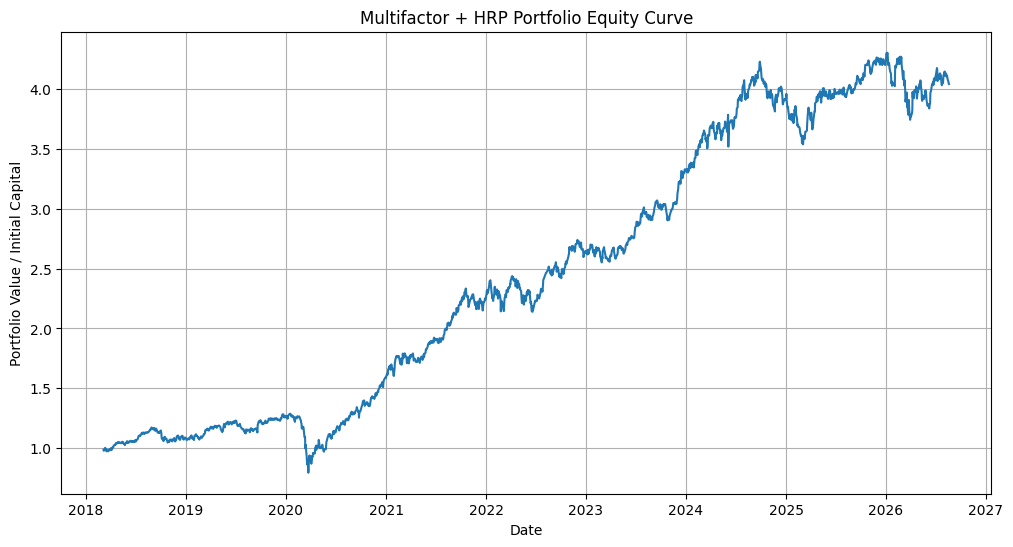

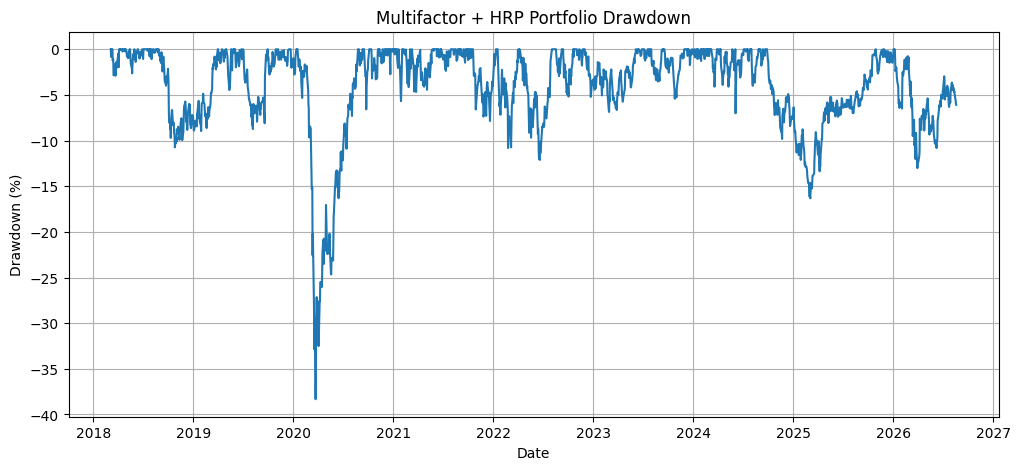

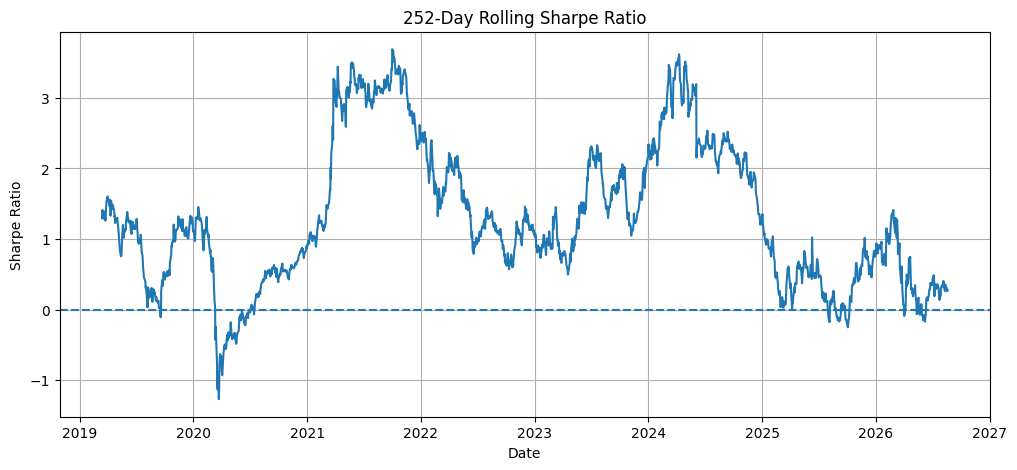


AVERAGE PORTFOLIO WEIGHTS
HDFCBANK.NS     0.128509
TCS.NS          0.118285
SUNPHARMA.NS    0.109206
LT.NS           0.097389
ITC.NS          0.092599
NTPC.NS         0.089152
INFY.NS         0.084941
RELIANCE.NS     0.081892
MARUTI.NS       0.070467
ICICIBANK.NS    0.067418
SBIN.NS         0.036668
ADANIENT.NS     0.023474
dtype: float64

PROJECT COMPLETED

Files saved:
multifactor_hrp_performance_summary.csv
multifactor_hrp_average_weights.csv
multifactor_hrp_drawdown.csv
multifactor_hrp_rolling_sharpe.csv


In [8]:
# ============================================================
# PART 7: PERFORMANCE ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 75)
print("MULTIFACTOR + HRP PERFORMANCE ANALYSIS")
print("=" * 75)

# ------------------------------------------------------------
# DAILY RETURNS
# ------------------------------------------------------------

portfolio_returns = portfolio_series.pct_change().dropna()

# ------------------------------------------------------------
# EQUITY CURVE
# ------------------------------------------------------------

equity_curve = portfolio_series / initial_capital

# ------------------------------------------------------------
# DRAWDOWN
# ------------------------------------------------------------

running_max = portfolio_series.cummax()

drawdown = (
    portfolio_series /
    running_max - 1
)

# ------------------------------------------------------------
# RISK METRICS
# ------------------------------------------------------------

annual_return = (
    portfolio_returns.mean() * 252
)

annual_volatility = (
    portfolio_returns.std() *
    np.sqrt(252)
)

sharpe_ratio = (
    annual_return /
    annual_volatility
)

max_drawdown = drawdown.min()

calmar_ratio = (
    annual_return /
    abs(max_drawdown)
)

# ------------------------------------------------------------
# TURNOVER
# ------------------------------------------------------------

turnover = (
    weight_history.diff()
    .abs()
    .sum(axis=1)
)

average_turnover = turnover.mean()

# ------------------------------------------------------------
# BEST / WORST DAYS
# ------------------------------------------------------------

best_day = portfolio_returns.max()
worst_day = portfolio_returns.min()

# ------------------------------------------------------------
# PERFORMANCE SUMMARY
# ------------------------------------------------------------

summary = pd.DataFrame({
    "Metric": [
        "Initial Capital",
        "Final Capital",
        "Total Return",
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "Calmar Ratio",
        "Average Turnover",
        "Best Day",
        "Worst Day"
    ],

    "Value": [
        f"₹{initial_capital:,.0f}",
        f"₹{portfolio_series.iloc[-1]:,.0f}",
        f"{(portfolio_series.iloc[-1] / initial_capital - 1) * 100:.2f}%",
        f"{annual_return * 100:.2f}%",
        f"{annual_volatility * 100:.2f}%",
        f"{sharpe_ratio:.3f}",
        f"{max_drawdown * 100:.2f}%",
        f"{calmar_ratio:.3f}",
        f"{average_turnover * 100:.2f}%",
        f"{best_day * 100:.2f}%",
        f"{worst_day * 100:.2f}%"
    ]
})

print("\n" + "=" * 75)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 75)

print(summary.to_string(index=False))

# ------------------------------------------------------------
# SAVE SUMMARY
# ------------------------------------------------------------

summary.to_csv(
    "multifactor_hrp_performance_summary.csv",
    index=False
)

# ------------------------------------------------------------
# EQUITY CURVE
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    equity_curve.index,
    equity_curve.values
)

plt.title(
    "Multifactor + HRP Portfolio Equity Curve"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value / Initial Capital")

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# DRAWDOWN
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    drawdown.index,
    drawdown.values * 100
)

plt.title(
    "Multifactor + HRP Portfolio Drawdown"
)

plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# ROLLING SHARPE
# ------------------------------------------------------------

rolling_return = (
    portfolio_returns
    .rolling(252)
    .mean() * 252
)

rolling_volatility = (
    portfolio_returns
    .rolling(252)
    .std() *
    np.sqrt(252)
)

rolling_sharpe = (
    rolling_return /
    rolling_volatility
)

plt.figure(figsize=(12, 5))

plt.plot(
    rolling_sharpe.index,
    rolling_sharpe.values
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "252-Day Rolling Sharpe Ratio"
)

plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# AVERAGE PORTFOLIO WEIGHTS
# ------------------------------------------------------------

average_weights = (
    weight_history
    .mean()
    .sort_values(
        ascending=False
    )
)

print("\n" + "=" * 75)
print("AVERAGE PORTFOLIO WEIGHTS")
print("=" * 75)

print(
    average_weights
)

# ------------------------------------------------------------
# SAVE ALL OUTPUTS
# ------------------------------------------------------------

average_weights.to_csv(
    "multifactor_hrp_average_weights.csv"
)

drawdown.to_csv(
    "multifactor_hrp_drawdown.csv"
)

rolling_sharpe.to_csv(
    "multifactor_hrp_rolling_sharpe.csv"
)

print("\n" + "=" * 75)
print("PROJECT COMPLETED")
print("=" * 75)

print("\nFiles saved:")
print("multifactor_hrp_performance_summary.csv")
print("multifactor_hrp_average_weights.csv")
print("multifactor_hrp_drawdown.csv")
print("multifactor_hrp_rolling_sharpe.csv")